# 03 - CNN Classifier (supervisionado)

Modelo 2 do projeto (Project 2 - MVTec AD). Ao contrario do autoencoder (nao supervisionado), aqui usamos uma **CNN supervisionada** em Keras para classificar `bottle` em **normal vs defeituoso**.

Segue o mesmo estilo das aulas: `train_test_split` -> normalizar -> `to_categorical` -> `Sequential` CNN -> `confusion_matrix` + `classification_report`.

(A comparacao final dos 3 metodos esta no notebook 05.)

In [1]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

## 1. Carregar as imagens

Juntamos todas as imagens da categoria `bottle`:
- **normais (label 0):** `train/good` + `test/good`
- **defeituosas (label 1):** todas as pastas de defeito em `test/` (broken_large, broken_small, contamination)

Nota: ao contrario do autoencoder, o modelo supervisionado **precisa** de exemplos defeituosos para treinar.

In [2]:
data_root = Path("../data/mvtec/bottle")
TAMANHO = 128  # redimensiona as imagens para 128x128

def carregar(pasta, label):
    """Carrega todas as .png de uma pasta como arrays e atribui um label."""
    X, y = [], []
    for img_path in sorted(pasta.glob("*.png")):
        img = Image.open(img_path).convert("RGB").resize((TAMANHO, TAMANHO))
        X.append(np.array(img))
        y.append(label)
    return X, y

X, y = [], []

# Normais (label 0)
for pasta in [data_root / "train" / "good", data_root / "test" / "good"]:
    Xi, yi = carregar(pasta, 0)
    X += Xi; y += yi

# Defeituosas (label 1)
for pasta in (data_root / "test").iterdir():
    if pasta.is_dir() and pasta.name != "good":
        Xi, yi = carregar(pasta, 1)
        X += Xi; y += yi

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)
print("Normais (0):", int((y == 0).sum()), "| Defeituosas (1):", int((y == 1).sum()))

Shape X: (292, 128, 128, 3)
Normais (0): 229 | Defeituosas (1): 63


## 2. Train/test split, normalizacao e one-hot

In [3]:
# Divide em treino/teste (stratify mantem a proporcao normal/defeito nos dois conjuntos)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalizacao
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encoding das labels (2 classes)
y_train_cat = to_categorical(y_train, 2)
y_test_cat = to_categorical(y_test, 2)

print("Treino:", x_train.shape, "| Teste:", x_test.shape)

Treino: (204, 128, 128, 3) | Teste: (88, 128, 128, 3)


## 3. Modelo CNN (Sequential)

In [4]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(TAMANHO, TAMANHO, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\maria\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Treino

Epoch 1/20



 1/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2500 - loss: 0.7134


 2/12 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3906 - loss: 1.1136


 3/12 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4688 - loss: 1.2428


 4/12 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5195 - loss: 1.2499

...


 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9750 - loss: 0.0735


 9/12 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9747 - loss: 0.0758


10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9747 - loss: 0.0770


11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9744 - loss: 0.0782


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9672 - loss: 0.0953 - val_accuracy: 0.7619 - val_loss: 0.2951


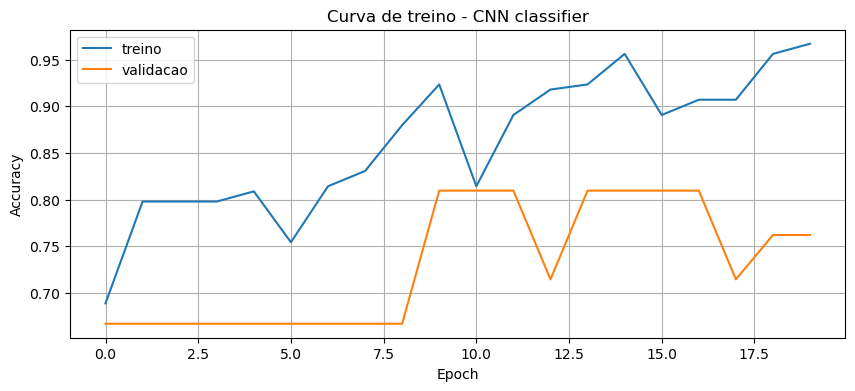

In [5]:
historico = model.fit(
    x_train, y_train_cat,
    epochs=20,
    batch_size=16,
    validation_split=0.1
)

plt.figure(figsize=(10, 4))
plt.plot(historico.history['accuracy'], label='treino')
plt.plot(historico.history['val_accuracy'], label='validacao')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.title('Curva de treino - CNN classifier')
plt.show()

## 5. Avaliacao (matriz de confusao + relatorio)

In [6]:
predictions = model.predict(x_test)

y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

print("Matriz de Confusao:")
print(confusion_matrix(y_true_classes, y_pred_classes))

print("\nRelatorio de Classificacao:")
print(classification_report(y_true_classes, y_pred_classes, target_names=['normal', 'defeito']))


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


Matriz de Confusao:
[[68  1]
 [ 3 16]]

Relatorio de Classificacao:
              precision    recall  f1-score   support

      normal       0.96      0.99      0.97        69
     defeito       0.94      0.84      0.89        19

    accuracy                           0.95        88
   macro avg       0.95      0.91      0.93        88
weighted avg       0.95      0.95      0.95        88



## 6. Varios exemplos classificados

Grelha com 8 imagens de teste (4 normais + 4 defeituosas) e a previsao do modelo. Verde = acertou, vermelho = errou.

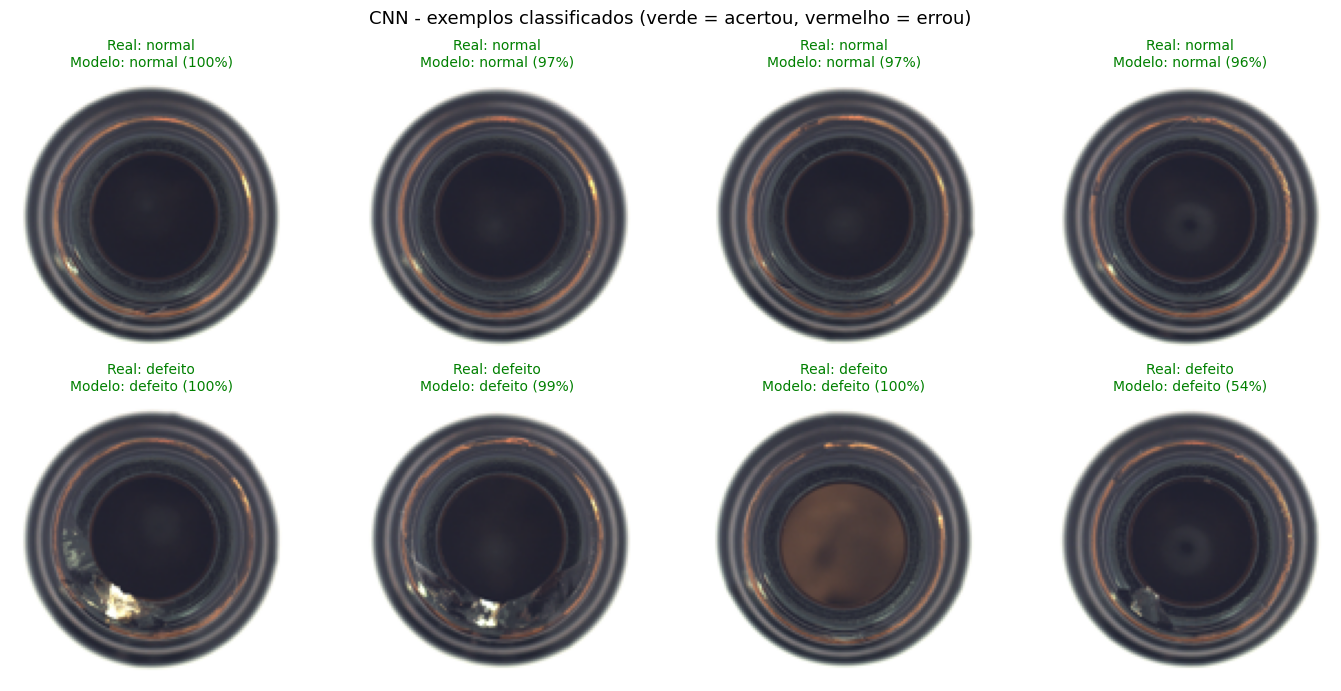

In [8]:
nomes = ['normal', 'defeito']
idx = np.concatenate([np.where(y_test == 0)[0][:4], np.where(y_test == 1)[0][:4]])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.ravel(), idx):
    prob = model.predict(x_test[i:i+1], verbose=0)[0]
    ax.imshow(x_test[i]); ax.axis('off')
    cor = 'green' if prob.argmax() == y_test[i] else 'red'
    ax.set_title(f"Real: {nomes[y_test[i]]}\nModelo: {nomes[prob.argmax()]} ({prob.max()*100:.0f}%)", color=cor, fontsize=10)

plt.suptitle("CNN - exemplos classificados (verde = acertou, vermelho = errou)", fontsize=13)
plt.tight_layout()
plt.show()